<a href="https://colab.research.google.com/github/deepshresthaa/A-Clustered-Graph-Based-Framework-for-Semantic-Research-Paper-Retrieval-and-Recommendation/blob/main/evaluation/evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 40.8 MB/s eta 0:00:00


## 1. Install Dependencies

This cell installs all required libraries, including specific versions to resolve potential conflicts.

In [ ]:

!pip install pandas==3.0.3
!pip install -q --extra-index-url=https://pypi.nvidia.com \
    "cudf-cu12" "cuml-cu12" "cupy-cuda12x"
!pip install -q numba sentence-transformers

print("All dependencies installed.")

All dependencies installed.


In [ ]:

!pip install -q sentence-transformers

import numpy as np
import cupy as cp
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-mpnet-base-v2')

def search_similar_paper(new_abstract, df, X_reduced, pca, kmeans, model):
    """
    Encodes a text abstract, maps it through PCA & KMeans, and returns
    the most similar paper from the matching cluster.
    """

    embedding_768 = model.encode(new_abstract, convert_to_numpy=True)


    new_vector_gpu = cp.asarray(embedding_768, dtype=np.float32).reshape(1, -1)


    norm = cp.linalg.norm(new_vector_gpu, axis=1, keepdims=True)
    new_vector_gpu = new_vector_gpu / cp.maximum(norm, 1e-12)

    # Step B: Transform from 768-dim to 100-dim using fitted PCA
    new_reduced_gpu = pca.transform(new_vector_gpu)

    # L2 normalize the 100-dim PCA vector
    norm_reduced = cp.linalg.norm(new_reduced_gpu, axis=1, keepdims=True)
    new_reduced_gpu = new_reduced_gpu / cp.maximum(norm_reduced, 1e-12)

    # Step C: Predict cluster using fitted K-Means
    predicted_cluster = int(kmeans.predict(new_reduced_gpu)[0])

    # Step D: Filter candidates in predicted cluster
    cluster_indices = np.where(df["cluster"].values == predicted_cluster)[0]

    # Step E: Cosine similarity search inside predicted cluster
    cluster_vectors = X_reduced[cluster_indices]
    similarities = cp.dot(cluster_vectors, new_reduced_gpu.squeeze())

    # Get highest similarity match
    best_pos = int(cp.argmax(similarities))
    best_idx = cluster_indices[best_pos]
    matched_paper = df.iloc[best_idx]

    return {
        "cluster": predicted_cluster,
        "similarity_score": float(similarities[best_pos]),
        "matched_title": matched_paper["title"],
        "matched_summary": matched_paper["summary"],
        "category": matched_paper["category"],
        "id": matched_paper["id"]
    }



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load Data and Perform Clustering

This section loads the dataset, creates embeddings, performs PCA for dimensionality reduction, and applies K-Means clustering on the GPU using `cuml` and `cupy`. It also saves the clustered and representative papers.

In [10]:
import gc
import time
import warnings
import numpy as np
import pandas as pd

# =========================
# Configuration
# =========================
DATA_PATH = "/content/drive/MyDrive/arxiv_clustering/01_arxiv_with_embeddings.parquet"
CLUSTERED_OUT_PATH = "/content/papers_clustered.csv"
REPRESENTATIVE_OUT_PATH = "/content/representative_papers.csv"

PCA_COMPONENTS = 100
N_CLUSTERS = 45
RANDOM_STATE = 42
EXPECTED_EMBED_DIM = 768

# =========================
# Backend detection (robust)
# =========================
USE_GPU = False
cp = None
normalize = None
PCA = None
KMeans = None

def setup_backend():
    global USE_GPU, cp, normalize, PCA, KMeans
    try:
        import cupy as _cp
        from cuml.preprocessing import normalize as _normalize
        from cuml.decomposition import PCA as _PCA
        from cuml.cluster import KMeans as _KMeans

        # ---- REAL GPU SMOKE TEST ----
        # catches cudaErrorInsufficientDriver at startup, not mid-pipeline
        _ = _cp.asarray([1.0], dtype=_cp.float32)
        _dev = _cp.cuda.runtime.getDevice()
        _name = _cp.cuda.runtime.getDeviceProperties(_dev)["name"].decode()

        cp = _cp
        normalize = _normalize
        PCA = _PCA
        KMeans = _KMeans
        USE_GPU = True
        print(f"Using GPU backend: cuML + CuPy | device={_name}")

    except Exception as e:
        USE_GPU = False
        warnings.warn(
            f"GPU backend unavailable ({type(e).__name__}: {e}). Falling back to CPU sklearn."
        )
        from sklearn.preprocessing import normalize as _normalize
        from sklearn.decomposition import PCA as _PCA
        from sklearn.cluster import KMeans as _KMeans

        normalize = _normalize
        PCA = _PCA
        KMeans = _KMeans
        print("Using CPU backend: scikit-learn")

setup_backend()

def free_gpu_memory():
    gc.collect()
    if USE_GPU and cp is not None:
        cp.get_default_memory_pool().free_all_blocks()

# =========================
# Load Data
# =========================
start_time = time.time()
print("Loading dataset...")
df = pd.read_parquet(DATA_PATH)
print("Dataset shape:", df.shape)

required_cols = ["id", "title", "category", "summary", "embedding"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

before = len(df)
df = df[df["embedding"].notna()].reset_index(drop=True)
after = len(df)
if after < before:
    print(f"Dropped {before - after} rows with null embeddings")

print("\nCreating embedding matrix...")
emb_list = [np.asarray(e, dtype=np.float32) for e in df["embedding"].values]
X = np.stack(emb_list, axis=0)

if X.ndim != 2:
    raise ValueError(f"Expected 2D embedding matrix, got shape {X.shape}")
if X.shape[1] != EXPECTED_EMBED_DIM:
    raise ValueError(f"Expected {EXPECTED_EMBED_DIM} dimensions, got {X.shape[1]}")

print(f"Embedding matrix shape: {X.shape}, dtype: {X.dtype}")

# =========================
# Normalize + PCA + KMeans
# =========================
if USE_GPU:
    try:
        print("Moving embeddings to GPU...")
        X_work = cp.asarray(X, dtype=cp.float32)
        del X, emb_list
        free_gpu_memory()

        print("L2 normalizing embeddings...")
        X_work = normalize(X_work, axis=1, norm="l2").astype(cp.float32, copy=False)

        print(f"\nRunning GPU PCA ({EXPECTED_EMBED_DIM} -> {PCA_COMPONENTS})...")
        pca_start = time.time()
        pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
        X_reduced = pca.fit_transform(X_work).astype(cp.float32, copy=False)
        print(f"PCA completed in {(time.time() - pca_start) / 60:.2f} minutes")
        print(f"Explained variance: {float(cp.asnumpy(cp.sum(pca.explained_variance_ratio_))):.4f}")

        del X_work
        free_gpu_memory()

        X_reduced = normalize(X_reduced, axis=1, norm="l2").astype(cp.float32, copy=False)

        print(f"\nRunning GPU K-Means ({N_CLUSTERS} clusters)...")
        km_start = time.time()
        kmeans = KMeans(
            n_clusters=N_CLUSTERS,
            random_state=RANDOM_STATE,
            n_init=10,
            max_iter=300,
            verbose=1
        )
        labels_gpu = kmeans.fit_predict(X_reduced)
        print(f"K-Means completed in {(time.time() - km_start) / 60:.2f} minutes")

        labels_np = cp.asnumpy(labels_gpu).astype(np.int32, copy=False)
        df["cluster"] = labels_np

        print("\nFinding representative papers...")
        centers = kmeans.cluster_centers_
        representative_papers = []

        for cluster_id in range(N_CLUSTERS):
            idx_gpu = cp.where(labels_gpu == cluster_id)[0]
            if int(idx_gpu.size) == 0:
                continue

            sims = cp.dot(X_reduced[idx_gpu], centers[cluster_id])
            best_pos = int(cp.argmax(sims).item())
            best_index = int(idx_gpu[best_pos].item())

            representative_papers.append({
                "cluster": cluster_id,
                "cluster_size": int(idx_gpu.size),
                "id": df.iloc[best_index]["id"],
                "title": df.iloc[best_index]["title"],
                "category": df.iloc[best_index]["category"],
                "summary": df.iloc[best_index]["summary"],
                "similarity_to_center": float(sims[best_pos].item())
            })

        X_reduced_cpu = cp.asnumpy(X_reduced).astype(np.float32, copy=False)

    except Exception as e:
        warnings.warn(f"GPU path failed at runtime ({type(e).__name__}: {e}). Re-running on CPU.")
        USE_GPU = False
        # restore CPU classes
        from sklearn.preprocessing import normalize
        from sklearn.decomposition import PCA
        from sklearn.cluster import KMeans

        # If X got deleted, rebuild from df embedding
        if "X" not in locals():
            emb_list = [np.asarray(e, dtype=np.float32) for e in df["embedding"].values]
            X = np.stack(emb_list, axis=0)

if not USE_GPU:
    X_work = X
    del emb_list
    gc.collect()

    print("L2 normalizing embeddings (CPU)...")
    X_work = normalize(X_work, axis=1, norm="l2").astype(np.float32, copy=False)

    print(f"\nRunning CPU PCA ({EXPECTED_EMBED_DIM} -> {PCA_COMPONENTS})...")
    pca_start = time.time()
    pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
    X_reduced = pca.fit_transform(X_work).astype(np.float32, copy=False)
    print(f"PCA completed in {(time.time() - pca_start) / 60:.2f} minutes")
    print(f"Explained variance: {float(np.sum(pca.explained_variance_ratio_)):.4f}")

    del X_work
    gc.collect()

    X_reduced = normalize(X_reduced, axis=1, norm="l2").astype(np.float32, copy=False)

    print(f"\nRunning CPU K-Means ({N_CLUSTERS} clusters)...")
    km_start = time.time()
    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=300,
        verbose=1
    )
    labels_np = kmeans.fit_predict(X_reduced).astype(np.int32, copy=False)
    print(f"K-Means completed in {(time.time() - km_start) / 60:.2f} minutes")

    df["cluster"] = labels_np

    print("\nFinding representative papers...")
    centers = kmeans.cluster_centers_
    representative_papers = []

    for cluster_id in range(N_CLUSTERS):
        idx = np.where(labels_np == cluster_id)[0]
        if idx.size == 0:
            continue

        sims = X_reduced[idx] @ centers[cluster_id]
        best_pos = int(np.argmax(sims))
        best_index = int(idx[best_pos])

        representative_papers.append({
            "cluster": cluster_id,
            "cluster_size": int(idx.size),
            "id": df.iloc[best_index]["id"],
            "title": df.iloc[best_index]["title"],
            "category": df.iloc[best_index]["category"],
            "summary": df.iloc[best_index]["summary"],
            "similarity_to_center": float(sims[best_pos])
        })

    X_reduced_cpu = np.asarray(X_reduced, dtype=np.float32)

representative_df = pd.DataFrame(representative_papers).sort_values("cluster").reset_index(drop=True)

print("\nSaving outputs...")
df.to_csv(CLUSTERED_OUT_PATH, index=False)
representative_df.to_csv(REPRESENTATIVE_OUT_PATH, index=False)
np.save("/content/X_reduced_cpu.npy", X_reduced_cpu)  # important for later cells

print(f"Saved clustered papers to: {CLUSTERED_OUT_PATH}")
print(f"Saved representative papers to: {REPRESENTATIVE_OUT_PATH}")
print("Saved reduced vectors to: /content/X_reduced_cpu.npy")
print(f"\nCLUSTERING COMPLETE in {(time.time() - start_time) / 60:.2f} minutes")

/tmp/ipykernel_1190/2338704915.py:51: UserWarning: GPU backend unavailable (ModuleNotFoundError: No module named 'cupy'). Falling back to CPU sklearn.
  warnings.warn(


Using CPU backend: scikit-learn
Loading dataset...
Dataset shape: (287421, 5)

Creating embedding matrix...
Embedding matrix shape: (287421, 768), dtype: float32
L2 normalizing embeddings (CPU)...

Running CPU PCA (768 -> 100)...
PCA completed in 0.14 minutes
Explained variance: 0.7398

Running CPU K-Means (45 clusters)...
Initialization complete
Iteration 0, inertia 313651.78125.
Iteration 1, inertia 197487.890625.
Iteration 2, inertia 193422.359375.
Iteration 3, inertia 191795.96875.
Iteration 4, inertia 190856.4375.
Iteration 5, inertia 190167.875.
Iteration 6, inertia 189644.984375.
Iteration 7, inertia 189256.25.
Iteration 8, inertia 188893.5625.
Iteration 9, inertia 188580.015625.
Iteration 10, inertia 188351.4375.
Iteration 11, inertia 188180.65625.
Iteration 12, inertia 188036.390625.
Iteration 13, inertia 187914.515625.
Iteration 14, inertia 187830.109375.
Iteration 15, inertia 187766.875.
Iteration 16, inertia 187720.453125.
Iteration 17, inertia 187686.234375.
Iteration 18, 

In [13]:
import os, time
for p in ["/content/papers_clustered.csv", "/content/representative_papers.csv","/content/X_reduced_cpu.npy"]:
    if os.path.exists(p):
        print(p, "size MB =", round(os.path.getsize(p)/1024/1024, 2))
    else:
        print(p, "not created yet")
print("time:", time.strftime("%H:%M:%S"))

/content/papers_clustered.csv size MB = 3798.68
/content/representative_papers.csv size MB = 0.06
/content/X_reduced_cpu.npy size MB = 109.64
time: 08:03:46


In [14]:
import shutil

# Copy the generated CSV files to your Google Drive
shutil.copy('/content/papers_clustered.csv', '/content/drive/MyDrive/papers_clustered.csv')
shutil.copy('/content/representative_papers.csv', '/content/drive/MyDrive/representative_papers.csv')
shutil.copy('/content/X_reduced_cpu.npy', '/content/drive/MyDrive/X_reduced_cpu.npy')

print("Files successfully copied to Google Drive!")

Files successfully copied to Google Drive!


## 4. Define Search Function and Helper

This section initializes the `SentenceTransformer` model and defines the `search_similar_paper` function, which uses the trained PCA and K-Means models to find similar papers based on a new abstract. A helper function to generate arXiv URLs is also provided.

In [15]:
from sentence_transformers import SentenceTransformer
import shutil

# Setup Sentence Transformer
embedding_model = SentenceTransformer('all-mpnet-base-v2')

# Matching Function
def search_similar_paper(new_abstract, df, X_reduced, pca, kmeans, model):
    """
    Encodes a text abstract, maps it through PCA & KMeans, and returns
    the most similar paper from the matching cluster.
    """
    # Step A: Generate 768-dim embedding for new abstract
    embedding_768 = model.encode(new_abstract, convert_to_numpy=True)

    # Format and send to GPU
    new_vector_gpu = cp.asarray(embedding_768, dtype=np.float32).reshape(1, -1)

    # L2 normalize raw 768-dim vector
    norm = cp.linalg.norm(new_vector_gpu, axis=1, keepdims=True)
    new_vector_gpu = new_vector_gpu / cp.maximum(norm, 1e-12)

    # Step B: Transform from 768-dim to 100-dim using fitted PCA
    new_reduced_gpu = pca.transform(new_vector_gpu)

    # L2 normalize the 100-dim PCA vector
    norm_reduced = cp.linalg.norm(new_reduced_gpu, axis=1, keepdims=True)
    new_reduced_gpu = new_reduced_gpu / cp.maximum(norm_reduced, 1e-12)

    # Step C: Predict cluster using fitted K-Means
    predicted_cluster = int(kmeans.predict(new_reduced_gpu)[0])

    # Step D: Filter candidates in predicted cluster
    cluster_indices = np.where(df["cluster"].values == predicted_cluster)[0]

    # Step E: Cosine similarity search inside predicted cluster
    cluster_vectors = X_reduced[cluster_indices]
    similarities = cp.dot(cluster_vectors, new_reduced_gpu.squeeze())

    # Get highest similarity match
    best_pos = int(cp.argmax(similarities))
    best_idx = cluster_indices[best_pos]
    matched_paper = df.iloc[best_idx]

    return {
        "cluster": predicted_cluster,
        "similarity_score": float(similarities[best_pos]),
        "matched_title": matched_paper["title"],
        "matched_summary": matched_paper["summary"],
        "category": matched_paper["category"],
        "id": matched_paper["id"]
    }

def get_arxiv_url(paper_id):
    # Remove 'abs-' prefix if present
    clean_id = paper_id.replace("abs-", "")
    return f"https://arxiv.org/abs/{clean_id}"

print("Search function and arXiv URL helper defined.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Search function and arXiv URL helper defined.


## 5. Example Usage and Copy to Drive

This demonstrates how to use the `search_similar_paper` function with a new abstract and then copies the generated output files to your Google Drive.

In [16]:
import shutil
import numpy as np
from sklearn.preprocessing import normalize as sk_normalize

def search_similar_paper_cpu(new_abstract, df, X_reduced, pca, kmeans, model):
    # 1) Embed new abstract on CPU
    new_embedding = model.encode([new_abstract], convert_to_numpy=True).astype(np.float32)  # (1, 768)

    # 2) PCA transform on CPU (works even if pca came from cuML)
    if hasattr(pca, "components_"):
        components = np.asarray(pca.components_, dtype=np.float32)
        X_pca = new_embedding @ components.T
        if hasattr(pca, "mean_") and pca.mean_ is not None:
            mean_ = np.asarray(pca.mean_, dtype=np.float32)
            X_pca = (new_embedding - mean_) @ components.T
    else:
        raise ValueError("PCA object has no components_")

    # 3) Normalize
    X_pca = sk_normalize(X_pca, norm="l2")

    # 4) Cluster centers to CPU
    centers = kmeans.cluster_centers_
    centers = np.asarray(centers, dtype=np.float32)
    centers = sk_normalize(centers, norm="l2")

    # 5) Predict cluster by max similarity to centers
    center_sims = (centers @ X_pca.T).ravel()
    cluster_id = int(np.argmax(center_sims))

    # 6) Find best matching paper inside predicted cluster
    labels = np.asarray(df["cluster"].values)
    idx = np.where(labels == cluster_id)[0]
    if idx.size == 0:
        raise ValueError(f"No papers found in predicted cluster {cluster_id}")

    Xr = np.asarray(X_reduced, dtype=np.float32)
    Xr_cluster = sk_normalize(Xr[idx], norm="l2")
    sims = (Xr_cluster @ X_pca.T).ravel()

    best_local = int(np.argmax(sims))
    best_index = int(idx[best_local])

    return {
        "cluster": cluster_id,
        "similarity_score": float(sims[best_local]),
        "matched_title": df.iloc[best_index]["title"],
        "matched_summary": df.iloc[best_index]["summary"],
        "id": df.iloc[best_index]["id"],
    }

new_abstract_text = """
Large Language Model (LLM)-based systems, i.e. interconnected elements that include
an LLM as a central component, such as conversational agents, are usually designed with
monolithic, static architectures that rely on a single, general-purpose LLM to handle all
user queries. However, these systems may be inefficient as different queries may require
different levels of reasoning, domain knowledge or pre-processing. While generalist LLMs
(e.g. GPT-4o, Claude-Sonnet) perform well across a wide range of tasks, they may incur
significant financial, energy and computational costs. These costs may be disproportionate
for simpler queries, resulting in unnecessary resource utilisation. A routing mechanism can
therefore be employed to route queries to more appropriate components, such as smaller or
specialised models, thereby improving efficiency and optimising resource consumption. This
survey aims to provide a comprehensive overview of routing strategies in LLM-based systems.
Specifically, it reviews when, why, and how routing should be integrated into LLM pipelines
to improve efficiency, scalability, and performance. We define the objectives to optimise, such
as cost minimisation and performance maximisation, and discuss the timing of routing within
the LLM workflow, whether it occurs before or after generation. We also detail the various
implementation strategies, including similarity-based, supervised, reinforcement learningbased, and generative methods. Practical considerations such as industrial applications and
current limitations are also examined, like standardising routing experiments, accounting
for non-financial costs, and designing adaptive strategies. Routing offers a practical way to
improve the efficiency of LLM-based systems. By formalising routing as a performance–cost
optimisation problem, this survey provides tools and directions to guide future research and
development of adaptive low-cost LLM-based systems.
"""

# Ensure X_reduced is CPU numpy (if you still have CuPy array, convert once)
if "cp" in globals():
    try:
        import cupy as cp
        if isinstance(X_reduced, cp.ndarray):
            X_reduced = cp.asnumpy(X_reduced)
    except Exception:
        pass

result = search_similar_paper_cpu(
    new_abstract=new_abstract_text,
    df=df,
    X_reduced=X_reduced,
    pca=pca,
    kmeans=kmeans,
    model=embedding_model
)

print(f"Predicted Cluster: {result['cluster']}")
print(f"Similarity Score:  {result['similarity_score']:.4f}")
print(f"Matched Title:     {result['matched_title']}")
print(f"\nMatched Summary:\n{result['matched_summary']}")
print(f"\nMatched paper id:\n{result['id']}")

paper_id = result["id"]
url = get_arxiv_url(paper_id)
print("arXiv Link:", url)

shutil.copy('/content/papers_clustered.csv', '/content/drive/MyDrive/papers_clustered.csv')
shutil.copy('/content/representative_papers.csv', '/content/drive/MyDrive/representative_papers.csv')

print("\nFiles successfully copied to Google Drive!")

Predicted Cluster: 2
Similarity Score:  0.9991
Matched Title:     Doing More with Less: A Survey on Routing Strategies for Resource Optimisation in Large Language Model-Based Systems

Matched Summary:
Large Language Model (LLM)-based systems, i.e. interconnected elements that include an LLM as a central component, such as conversational agents, are usually designed with monolithic, static architectures that rely on a single, general-purpose LLM to handle all user queries. However, these systems may be inefficient as different queries may require different levels of reasoning, domain knowledge or pre-processing. While generalist LLMs (e.g. GPT-4o, Claude-Sonnet) perform well across a wide range of tasks, they may incur significant financial, energy and computational costs. These costs may be disproportionate for simpler queries, resulting in unnecessary resource utilisation. A routing mechanism can therefore be employed to route queries to more appropriate components, such as smaller or

In [18]:
# ============================================================
# CLUSTERING EVALUATION — CPU-safe version (no CuPy required)
# Add this as a new cell after df["cluster"] exists
# ============================================================

!pip install -q scikit-learn umap-learn matplotlib seaborn wordcloud networkx pyvis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert X_reduced to CPU numpy safely (works whether it's NumPy or CuPy)
if "X_reduced" not in globals():
    raise ValueError("X_reduced not found in memory. Re-run the clustering cell first.")

try:
    import cupy as cp
    if isinstance(X_reduced, cp.ndarray):
        X_reduced_cpu = cp.asnumpy(X_reduced)
    else:
        X_reduced_cpu = np.asarray(X_reduced)
except Exception:
    X_reduced_cpu = np.asarray(X_reduced)

labels = df["cluster"].to_numpy()

print("X_reduced_cpu shape:", X_reduced_cpu.shape)
print("labels shape:", labels.shape)
print("unique clusters:", len(np.unique(labels)))

X_reduced_cpu shape: (287421, 100)
labels shape: (287421,)
unique clusters: 45


In [19]:
# ============================================================
# PART A — INTERNAL VALIDATION
# (no ground truth needed — judges compactness/separation of clusters)
# ============================================================
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# NOTE: full silhouette on 100k+ rows is slow -> sample for the score
SAMPLE_SIZE = min(20000, len(X_reduced_cpu))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_reduced_cpu), SAMPLE_SIZE, replace=False)

sil = silhouette_score(X_reduced_cpu[sample_idx], labels[sample_idx])
dbi = davies_bouldin_score(X_reduced_cpu, labels)
chi = calinski_harabasz_score(X_reduced_cpu, labels)

internal_metrics = pd.DataFrame({
    "Metric": ["Silhouette Score (higher=better, range -1..1)",
               "Davies-Bouldin Index (lower=better)",
               "Calinski-Harabasz Index (higher=better)"],
    "Value": [round(sil, 4), round(dbi, 4), round(chi, 2)]
})
print(internal_metrics.to_string(index=False))
internal_metrics.to_csv("/content/internal_metrics.csv", index=False)


                                       Metric       Value
Silhouette Score (higher=better, range -1..1)    0.061900
          Davies-Bouldin Index (lower=better)    2.802400
      Calinski-Harabasz Index (higher=better) 3524.120117


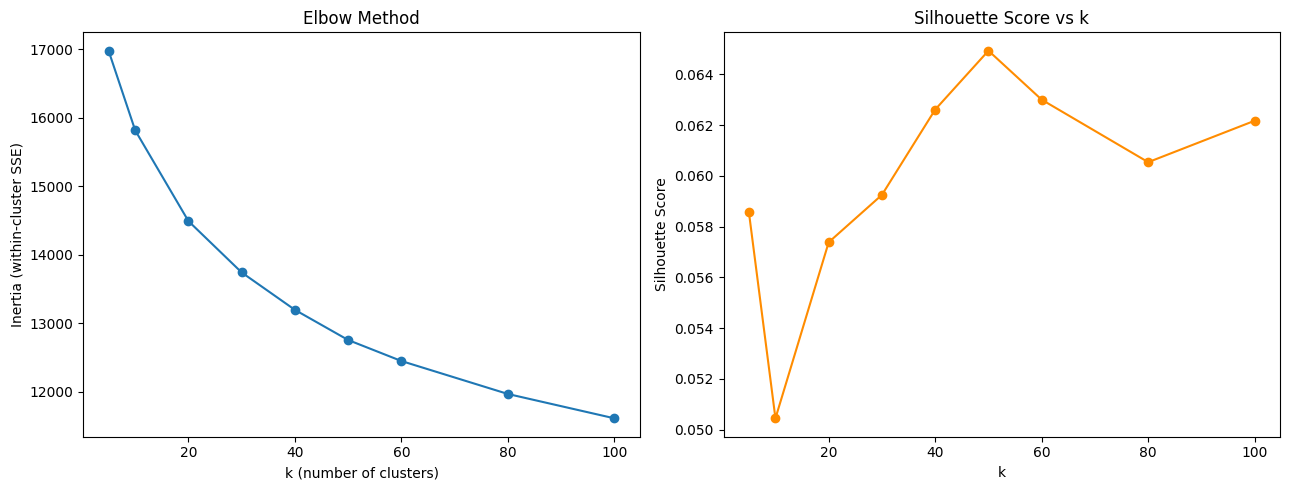

Saved: /content/elbow_silhouette.png


In [20]:

# ============================================================
# PART B — ELBOW METHOD + SILHOUETTE ACROSS K (CPU VERSION)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# If not already defined, create a sample index
if "sample_idx" not in globals():
    n = len(X_reduced_cpu)
    sample_size = min(20000, n)  # adjust if needed
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(n, size=sample_size, replace=False)

k_values = [5, 10, 20, 30, 40, 50, 60, 80, 100]
inertias, sil_scores = [], []

X_sample = np.asarray(X_reduced_cpu[sample_idx], dtype=np.float32)

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300,
        verbose=0
    )
    lbl = km.fit_predict(X_sample)
    inertias.append(float(km.inertia_))
    sil_scores.append(float(silhouette_score(X_sample, lbl)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

axes[1].plot(k_values, sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("/content/elbow_silhouette.png", dpi=150)
plt.show()
print("Saved: /content/elbow_silhouette.png")

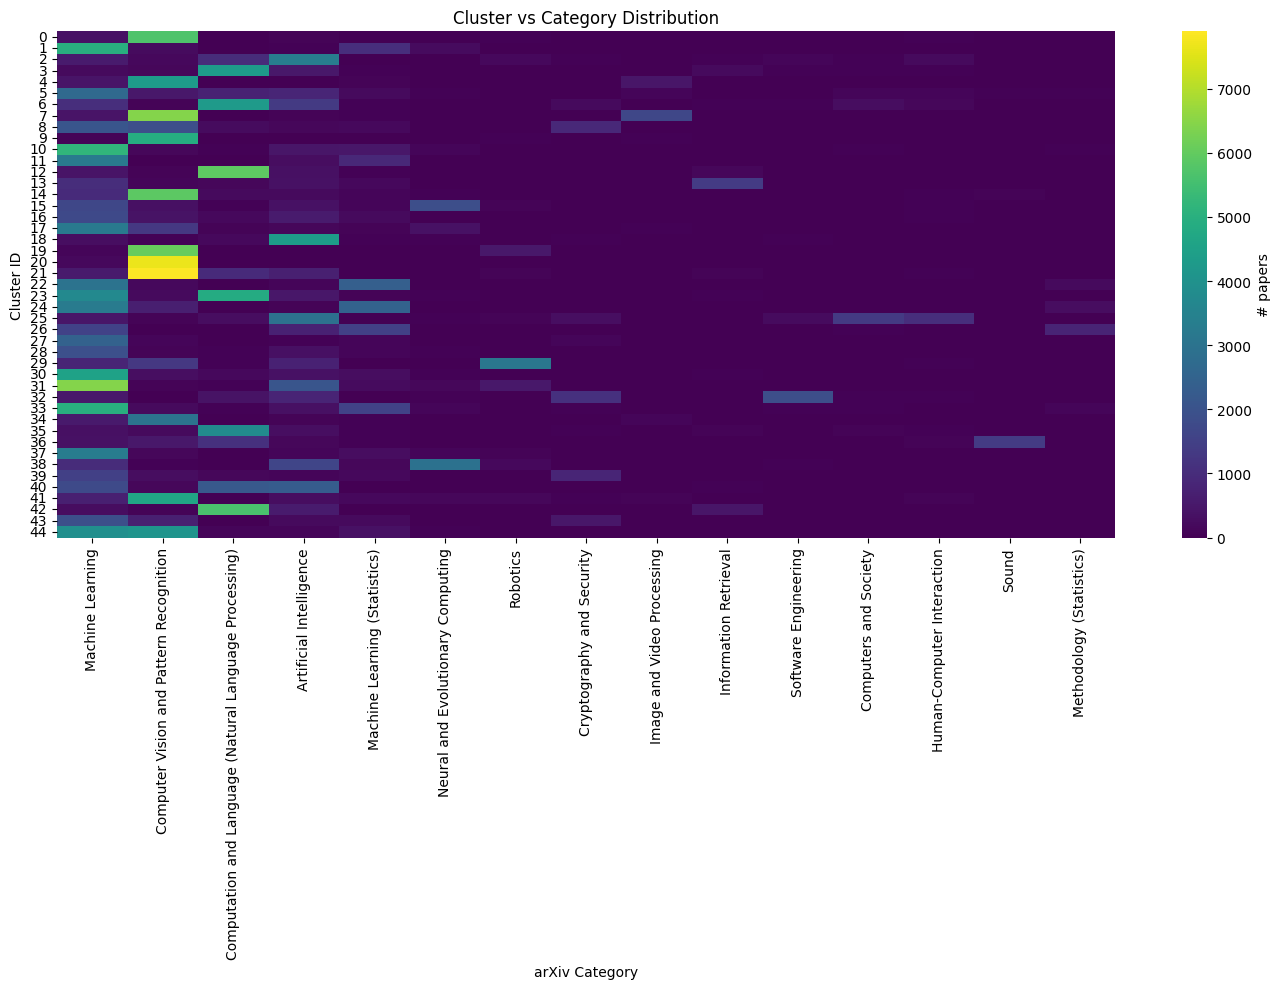

In [21]:
# ============================================================
# PART D — CLUSTER x CATEGORY HEATMAP
# Shows visually whether each cluster maps cleanly to a category,
# or is a mixed bag (useful evidence for the report)
# ============================================================
crosstab = pd.crosstab(df["cluster"], df["category"])
# Keep only top 15 categories by frequency to keep it readable
top_cats = df["category"].value_counts().head(15).index
crosstab_top = crosstab[top_cats]

plt.figure(figsize=(14, 10))
sns.heatmap(crosstab_top, cmap="viridis", cbar_kws={"label": "# papers"})
plt.title("Cluster vs Category Distribution")
plt.xlabel("arXiv Category")
plt.ylabel("Cluster ID")
plt.tight_layout()
plt.savefig("/content/cluster_category_heatmap.png", dpi=150)
plt.show()

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


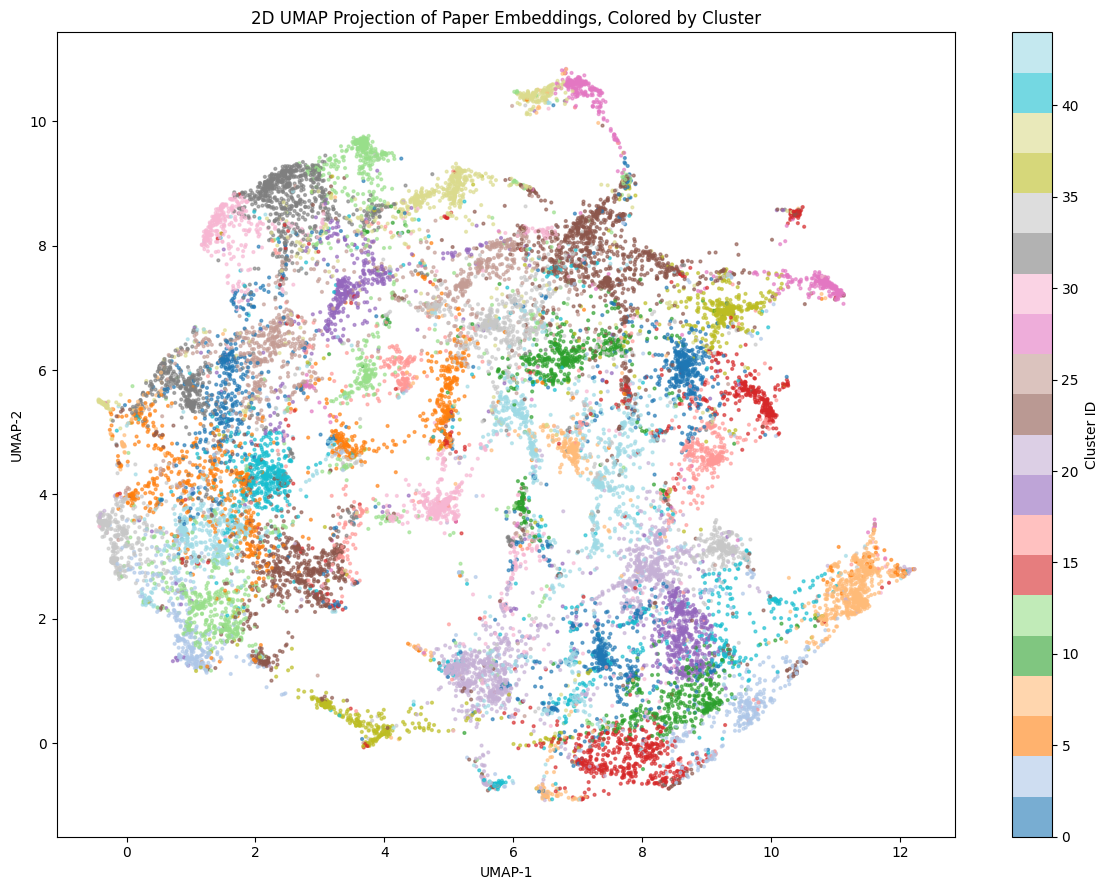

In [22]:
# ============================================================
# PART E — 2D PROJECTION FOR VISUAL INSPECTION (UMAP)
# t-SNE also works but UMAP is faster and preserves global structure better
# ============================================================
import umap

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
# Use the same sample to keep runtime reasonable
emb_2d = reducer.fit_transform(X_reduced_cpu[sample_idx])

plt.figure(figsize=(12, 9))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels[sample_idx],
                       cmap="tab20", s=4, alpha=0.6)
plt.title("2D UMAP Projection of Paper Embeddings, Colored by Cluster")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.savefig("/content/umap_clusters.png", dpi=150)
plt.show()


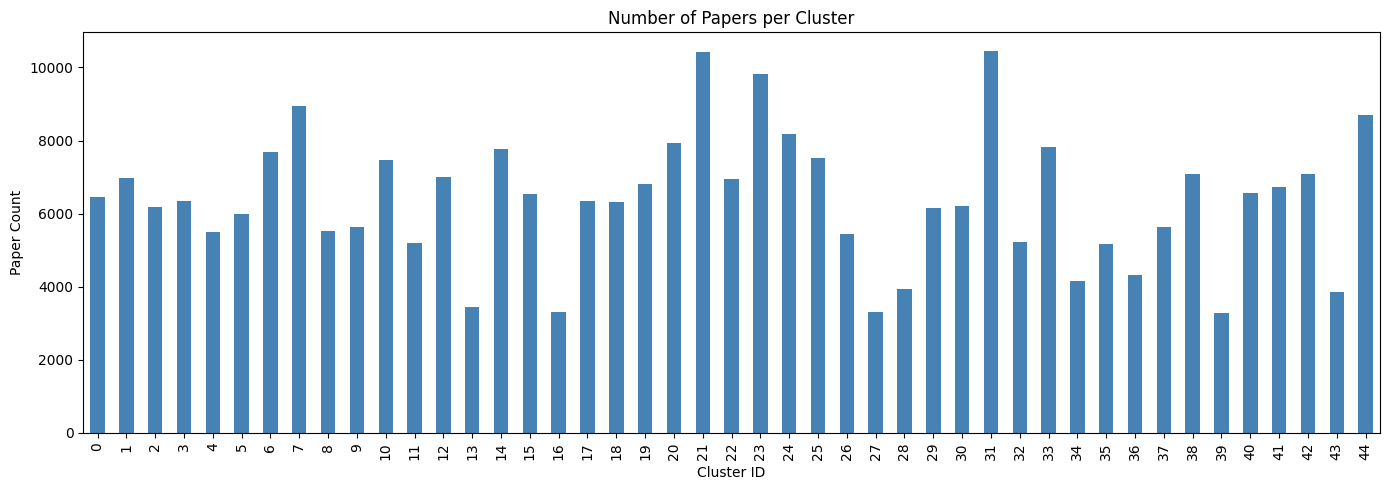

In [25]:
# ============================================================
# PART F — CLUSTER SIZE DISTRIBUTION (bar chart)
# ============================================================
cluster_sizes = df["cluster"].value_counts().sort_index()
plt.figure(figsize=(14, 5))
cluster_sizes.plot(kind="bar", color="steelblue")
plt.title("Number of Papers per Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Paper Count")
plt.tight_layout()
plt.savefig("/content/cluster_sizes.png", dpi=150)
plt.show()

In [23]:
# ============================================================
# PART G — TOP KEYWORDS PER CLUSTER (c-TF-IDF style)
# Gives interpretable "what is this cluster about" labels —
# essential table for a data mining report
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

def top_keywords_per_cluster(df, text_col="summary", cluster_col="cluster", top_n=8):
    results = []
    for cid in sorted(df[cluster_col].unique()):
        texts = df.loc[df[cluster_col] == cid, text_col].astype(str).tolist()
        if len(texts) < 2:
            continue
        vec = TfidfVectorizer(stop_words="english", max_features=2000)
        tfidf = vec.fit_transform(texts)
        mean_scores = np.asarray(tfidf.mean(axis=0)).ravel()
        top_idx = mean_scores.argsort()[::-1][:top_n]
        terms = [vec.get_feature_names_out()[i] for i in top_idx]
        results.append({"cluster": cid, "size": len(texts), "top_keywords": ", ".join(terms)})
    return pd.DataFrame(results)

keyword_table = top_keywords_per_cluster(df)
keyword_table.to_csv("/content/cluster_keywords.csv", index=False)
print(keyword_table.to_string(index=False))



 cluster  size                                                                       top_keywords
       0  6445                         video, temporal, motion, action, based, human, model, data
       1  6979                networks, learning, neural, training, network, deep, gradient, data
       2  6181                      agent, agents, llm, models, language, reasoning, model, based
       3  6346                            language, text, data, based, model, models, paper, word
       4  5498               image, images, resolution, model, quality, based, diffusion, methods
       5  6003                   data, clinical, models, model, learning, medical, patient, based
       6  7675                        llms, models, model, language, human, llm, data, evaluation
       7  8951                segmentation, data, image, model, learning, images, models, medical
       8  5522            adversarial, attacks, models, model, attack, robustness, training, data
       9  5648      

In [26]:
# PART H — FINAL SUMMARY TABLE (merge everything into one report table)
# ============================================================
summary_table = keyword_table.merge(
    representative_df[["cluster", "title", "category"]],
    on="cluster", how="left"
).rename(columns={"title": "representative_paper_title", "category": "representative_category"})
summary_table.to_csv("/content/cluster_summary_report.csv", index=False)
print(summary_table.to_string(index=False))

# Copy everything to Drive for your report
import shutil
for f in ["internal_metrics.csv", "cluster_keywords.csv",
          "cluster_summary_report.csv", "elbow_silhouette.png",
          "cluster_category_heatmap.png", "umap_clusters.png", "cluster_sizes.png"]:
    shutil.copy(f"/content/{f}", f"/content/drive/MyDrive/{f}")
print("Evaluation artifacts saved to Drive.")

 cluster  size                                                                       top_keywords                                                                                                                   representative_paper_title                                representative_category
       0  6445                         video, temporal, motion, action, based, human, model, data                                                                      Fine-grained Activity Recognition with Holistic and Pose based Features                Computer Vision and Pattern Recognition
       1  6979                networks, learning, neural, training, network, deep, gradient, data                                                                                             Gradient Descent Quantizes ReLU Network Features                          Machine Learning (Statistics)
       2  6181                      agent, agents, llm, models, language, reasoning, model, based                     

In [27]:
# ============================================================
# RECOVERY CELL v2: robust embedding parser + rebuild X_reduced_cpu
# ============================================================
import os
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

CLUSTERED_CSV = "/content/papers_clustered.csv"
PCA_COMPONENTS = 100
RANDOM_STATE = 42

if not os.path.exists(CLUSTERED_CSV):
    raise FileNotFoundError(f"Missing file: {CLUSTERED_CSV}")

print("[INFO] Loading clustered CSV...")
df = pd.read_csv(CLUSTERED_CSV)
print("[INFO] df shape:", df.shape)
print("[INFO] columns:", list(df.columns))

if "cluster" not in df.columns:
    raise ValueError("cluster column missing in papers_clustered.csv")
if "embedding" not in df.columns:
    raise ValueError("embedding column missing in papers_clustered.csv")

def parse_embedding(x):
    # already array-like
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.asarray(x, dtype=np.float32)
        return arr if arr.ndim == 1 and arr.size > 0 else None

    # string formats
    if isinstance(x, str):
        s = x.strip()
        if len(s) == 0:
            return None

        # remove brackets if present
        if s.startswith("[") and s.endswith("]"):
            s = s[1:-1].strip()

        # normalize separators: comma OR whitespace/newline/tab
        # split by commas or any whitespace run
        parts = re.split(r"[,\s]+", s)
        parts = [p for p in parts if p != ""]

        try:
            arr = np.asarray(parts, dtype=np.float32)
            return arr if arr.ndim == 1 and arr.size > 0 else None
        except Exception:
            return None

    return None

print("[INFO] Parsing embeddings...")
emb = [parse_embedding(v) for v in df["embedding"].values]
valid_mask = np.array([e is not None for e in emb], dtype=bool)

if valid_mask.sum() == 0:
    raise ValueError("No valid embeddings parsed from CSV.")

if valid_mask.sum() < len(df):
    print(f"[WARN] Dropping {len(df)-valid_mask.sum()} rows with unparseable embeddings")

df = df.loc[valid_mask].reset_index(drop=True)
emb = [e for e in emb if e is not None]

# keep only most common dimensionality
dims = np.array([e.shape[0] for e in emb], dtype=int)
vals, counts = np.unique(dims, return_counts=True)
common_dim = int(vals[np.argmax(counts)])

keep = dims == common_dim
if keep.sum() < len(emb):
    print(f"[WARN] Dropping {len(emb)-keep.sum()} rows with non-{common_dim}D embeddings")

df = df.loc[keep].reset_index(drop=True)
emb = [emb[i] for i in range(len(emb)) if keep[i]]

# enforce numeric cluster
df["cluster"] = pd.to_numeric(df["cluster"], errors="coerce")
before = len(df)
df = df[df["cluster"].notna()].copy()
df["cluster"] = df["cluster"].astype(int)
after = len(df)
if after < before:
    print(f"[WARN] Dropped {before-after} rows with invalid cluster labels")

X = np.stack(emb).astype(np.float32)
print("[INFO] Embedding matrix:", X.shape)

print("[INFO] Normalizing + PCA...")
Xn = normalize(X, norm="l2")
pca = PCA(n_components=min(PCA_COMPONENTS, Xn.shape[1]), random_state=RANDOM_STATE)
X_reduced_cpu = pca.fit_transform(Xn).astype(np.float32)
X_reduced_cpu = normalize(X_reduced_cpu, norm="l2").astype(np.float32)

SAMPLE_SIZE = min(20000, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), SAMPLE_SIZE, replace=False)

print("[OK] Rebuilt X_reduced_cpu:", X_reduced_cpu.shape)
print("[OK] df shape:", df.shape)
print("[OK] sample_idx:", sample_idx.shape)

# save for reuse
np.save("/content/X_reduced_cpu.npy", X_reduced_cpu)
print("[OK] Saved /content/X_reduced_cpu.npy")

[INFO] Loading clustered CSV...
[INFO] df shape: (287421, 6)
[INFO] columns: ['id', 'title', 'category', 'summary', 'embedding', 'cluster']
[INFO] Parsing embeddings...
[INFO] Embedding matrix: (287421, 768)
[INFO] Normalizing + PCA...
[OK] Rebuilt X_reduced_cpu: (287421, 100)
[OK] df shape: (287421, 6)
[OK] sample_idx: (20000,)
[OK] Saved /content/X_reduced_cpu.npy


In [28]:
# ============================================================
# PART I — KNOWLEDGE GRAPH
# ============================================================
import numpy as np
import shutil
import networkx as nx
from pyvis.network import Network
from sklearn.preprocessing import normalize as sk_normalize

def build_knowledge_graph(df, X_reduced_cpu, sample_idx, k_neighbors=3, max_nodes=500):
    sub_idx = np.asarray(sample_idx[:max_nodes], dtype=int)
    sub_df = df.iloc[sub_idx].reset_index(drop=True)
    sub_vecs = np.asarray(X_reduced_cpu[sub_idx], dtype=np.float32)
    sub_vecs = sk_normalize(sub_vecs, norm="l2")

    G = nx.Graph()

    # Paper nodes
    for _, row in sub_df.iterrows():
        G.add_node(
            f"P_{row['id']}",
            label=str(row["title"])[:40],
            type="paper",
            cluster=int(row["cluster"]),
            category=str(row["category"])
        )

    # Cluster nodes + edges
    for cid in sorted(sub_df["cluster"].unique()):
        G.add_node(f"C_{int(cid)}", label=f"Cluster {int(cid)}", type="cluster")
    for _, row in sub_df.iterrows():
        G.add_edge(f"P_{row['id']}", f"C_{int(row['cluster'])}", relation="BELONGS_TO")

    # Category nodes + edges
    for cat in sub_df["category"].astype(str).unique():
        G.add_node(f"CAT_{cat}", label=cat, type="category")
    for _, row in sub_df.iterrows():
        G.add_edge(f"P_{row['id']}", f"CAT_{str(row['category'])}", relation="TAGGED")

    # Similarity edges (top-k)
    sim_matrix = sub_vecs @ sub_vecs.T
    n = sim_matrix.shape[0]

    for i in range(n):
        sims = sim_matrix[i]
        nn_idx = np.argsort(sims)[::-1]
        nn_idx = nn_idx[nn_idx != i][:k_neighbors]
        src_id = sub_df.iloc[i]["id"]

        for j in nn_idx:
            dst_id = sub_df.iloc[j]["id"]
            G.add_edge(
                f"P_{src_id}",
                f"P_{dst_id}",
                relation="SIMILAR_TO",
                weight=float(sims[j])
            )

    return G

G = build_knowledge_graph(df, X_reduced_cpu, sample_idx, k_neighbors=3, max_nodes=500)

print(f"Knowledge graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("Density:", nx.density(G))
print("Connected components:", nx.number_connected_components(G))

degrees = dict(G.degree())
top_hub_papers = sorted(
    [(n, d) for n, d in degrees.items() if n.startswith("P_")],
    key=lambda x: -x[1]
)[:10]
print("Top hub papers:", top_hub_papers)

# Interactive HTML
net = Network(height="800px", width="100%", notebook=False, cdn_resources="in_line")
color_map = {"paper": "#6baed6", "cluster": "#fd8d3c", "category": "#74c476"}

for node, attrs in G.nodes(data=True):
    net.add_node(
        node,
        label=attrs.get("label", node),
        color=color_map.get(attrs.get("type"), "#cccccc"),
        title=attrs.get("type", "")
    )

for u, v, attrs in G.edges(data=True):
    net.add_edge(u, v, title=attrs.get("relation", ""), value=attrs.get("weight", 1.0))

out_local = "/content/knowledge_graph.html"
out_drive = "/content/drive/MyDrive/knowledge_graph.html"

net.write_html(out_local)
shutil.copy(out_local, out_drive)
print(f"Saved: {out_local}")
print(f"Copied: {out_drive}")

Knowledge graph: 586 nodes, 2058 edges
Density: 0.012006650914500743
Connected components: 1
Top hub papers: [('P_abs-2508.13936v1', 12), ('P_abs-2509.08755v1', 12), ('P_abs-2601.03093v3', 11), ('P_abs-2510.05577v1', 11), ('P_abs-2511.22486v4', 11), ('P_abs-1504.05766v1', 11), ('P_abs-2412.17964v1', 10), ('P_abs-1804.00097v1', 10), ('P_abs-1804.05950v2', 10), ('P_abs-2212.04971v2', 10)]
Saved: /content/knowledge_graph.html
Copied: /content/drive/MyDrive/knowledge_graph.html


In [4]:
# ============================================================
# FINAL K-RANGE EXPERIMENT — THE ONE YOU RUN FOR THE PAPER
# Uses full KMeans(n_init=10), same config as your final model.
# This will take a while (roughly 90-120 minutes based on your
# earlier single-K runs) — start it and let it finish, don't
# re-run it.
# ============================================================
import time
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42

# --- Reuse existing state; do not recompute embeddings/PCA ---
if "X_reduced_cpu" not in globals():
    X_reduced_cpu = np.load("/content/X_reduced_cpu.npy")

N_ROWS = X_reduced_cpu.shape[0]

# Fixed, reproducible sample used for Silhouette ONLY
SAMPLE_SIZE = min(20000, N_ROWS)
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(N_ROWS, size=SAMPLE_SIZE, replace=False)

# --- Candidate K values: coarse range + fine bracket around 40-55 ---
K_VALUES = sorted(set(
    [5, 10, 15, 20, 25, 30, 35, 40, 42, 45, 48, 50, 52, 55, 60, 70, 80, 100]
))

results = []
for k in K_VALUES:
    t0 = time.time()

    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    labels = km.fit_predict(X_reduced_cpu)
    runtime_sec = time.time() - t0

    sil = silhouette_score(X_reduced_cpu[sample_idx], labels[sample_idx])
    dbi = davies_bouldin_score(X_reduced_cpu, labels)
    chi = calinski_harabasz_score(X_reduced_cpu, labels)

    results.append({
        "K": k,
        "Inertia": float(km.inertia_),
        "Silhouette": float(sil),
        "Davies_Bouldin": float(dbi),
        "Calinski_Harabasz": float(chi),
        "Runtime_sec": round(runtime_sec, 1),
    })
    print(f"K={k:>3} | inertia={km.inertia_:>12.1f} | sil={sil:.4f} | "
          f"DBI={dbi:.4f} | CH={chi:.1f} | {runtime_sec:.1f}s")

tuning_df = pd.DataFrame(results).sort_values("K").reset_index(drop=True)
tuning_df.to_csv("/content/k_tuning_results.csv", index=False)
print("\nSaved: /content/k_tuning_results.csv")
tuning_df

K=  5 | inertia=    244193.9 | sil=0.0584 | DBI=3.5800 | CH=12703.3 | 38.6s
K= 10 | inertia=    227215.2 | sil=0.0512 | DBI=3.3650 | CH=8454.1 | 34.7s
K= 15 | inertia=    215710.7 | sil=0.0572 | DBI=3.1619 | CH=6819.1 | 60.0s
K= 20 | inertia=    208037.9 | sil=0.0565 | DBI=3.0247 | CH=5767.7 | 96.1s
K= 25 | inertia=    202524.6 | sil=0.0579 | DBI=3.0089 | CH=5016.3 | 95.2s
K= 30 | inertia=    197692.5 | sil=0.0596 | DBI=2.9907 | CH=4495.1 | 124.4s
K= 35 | inertia=    193459.8 | sil=0.0610 | DBI=2.9098 | CH=4102.9 | 155.4s
K= 40 | inertia=    189732.1 | sil=0.0636 | DBI=2.7947 | CH=3791.7 | 162.3s
K= 42 | inertia=    188475.3 | sil=0.0619 | DBI=2.8357 | CH=3677.4 | 178.3s
K= 45 | inertia=    186654.3 | sil=0.0619 | DBI=2.8024 | CH=3524.1 | 191.3s
K= 48 | inertia=    184718.0 | sil=0.0633 | DBI=2.7539 | CH=3397.7 | 192.9s
K= 50 | inertia=    183425.6 | sil=0.0645 | DBI=2.7253 | CH=3323.4 | 206.6s
K= 52 | inertia=    182447.4 | sil=0.0645 | DBI=2.7424 | CH=3240.3 | 195.6s
K= 55 | inertia=

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Runtime_sec
0,5,244193.890625,0.058376,3.579982,12703.338867,38.6
1,10,227215.218750,0.051221,3.364965,8454.138672,34.7
2,15,215710.718750,0.057167,3.161880,6819.095215,60.0
3,20,208037.937500,0.056532,3.024660,5767.674805,96.1
4,25,202524.562500,0.057910,3.008860,5016.307129,95.2
5,30,197692.500000,0.059647,2.990742,4495.117188,124.4
6,35,193459.765625,0.061023,2.909846,4102.884766,155.4
7,40,189732.078125,0.063552,2.794659,3791.688232,162.3
8,42,188475.328125,0.061867,2.835704,3677.388672,178.3
9,45,186654.343750,0.061878,2.802435,3524.124023,191.3


In [2]:
# ============================================================
# FULL K-RANGE HYPERPARAMETER EXPERIMENT (with fast/exploration toggle)
# Reuses existing X_reduced_cpu (already PCA-reduced + L2-normalized).
# Replaces the earlier version — this is the ONE cell to run.
# ============================================================
import time
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --------------------------------------------------------------
# TOGGLE — this is the only thing you switch back and forth.
#
#   FAST_EXPLORATION = True
#       -> MiniBatchKMeans, n_init=3
#       -> use this WHILE you're still deciding which K values to test
#          (fast, cheap, run it as many times as you want)
#
#   FAST_EXPLORATION = False
#       -> KMeans, n_init=10  (identical config to your final model)
#       -> use this for the ONE run whose numbers actually go in the
#          paper — Table 1/2, Figures 1-6, everything downstream
# --------------------------------------------------------------
FAST_EXPLORATION = True   # <-- flip to False for the run you'll publish

RANDOM_STATE = 42

# --- Reuse existing state; do not recompute embeddings/PCA ---
if "X_reduced_cpu" not in globals():
    X_reduced_cpu = np.load("/content/X_reduced_cpu.npy")

N_ROWS = X_reduced_cpu.shape[0]

# Fixed, reproducible sample used for Silhouette ONLY
SAMPLE_SIZE = min(20000, N_ROWS)
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(N_ROWS, size=SAMPLE_SIZE, replace=False)

# --- Candidate K values: coarse range + fine bracket around 40-55 ---
K_VALUES = sorted(set(
    [5, 10, 15, 20, 25, 30, 35, 40, 42, 45, 48, 50, 52, 55, 60, 70, 80, 100]
))

results = []
for k in K_VALUES:
    t0 = time.time()

    if FAST_EXPLORATION:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=3,
            max_iter=300,
            batch_size=4096,
        )
    else:
        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            max_iter=300,
            random_state=RANDOM_STATE,
            verbose=0,
        )

    labels = km.fit_predict(X_reduced_cpu)
    runtime_sec = time.time() - t0

    sil = silhouette_score(X_reduced_cpu[sample_idx], labels[sample_idx])
    dbi = davies_bouldin_score(X_reduced_cpu, labels)   # cheap: full data
    chi = calinski_harabasz_score(X_reduced_cpu, labels)  # cheap: full data

    results.append({
        "K": k,
        "Inertia": float(km.inertia_),
        "Silhouette": float(sil),
        "Davies_Bouldin": float(dbi),
        "Calinski_Harabasz": float(chi),
        "Runtime_sec": round(runtime_sec, 1),
        "Estimator": "MiniBatchKMeans" if FAST_EXPLORATION else "KMeans",
    })
    print(f"K={k:>3} | {results[-1]['Estimator']:>15} | inertia={km.inertia_:>12.1f} | "
          f"sil={sil:.4f} | DBI={dbi:.4f} | CH={chi:.1f} | {runtime_sec:.1f}s")

tuning_df = pd.DataFrame(results).sort_values("K").reset_index(drop=True)

# Save to a different file depending on mode, so you never accidentally
# feed exploration-run numbers into your publication tables/figures.
out_path = "/content/k_tuning_results_EXPLORATION.csv" if FAST_EXPLORATION \
    else "/content/k_tuning_results.csv"
tuning_df.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
tuning_df

K=  5 | MiniBatchKMeans | inertia=    246515.7 | sil=0.0461 | DBI=3.8864 | CH=11984.9 | 1.1s
K= 10 | MiniBatchKMeans | inertia=    229800.7 | sil=0.0495 | DBI=3.5600 | CH=8022.3 | 0.5s
K= 15 | MiniBatchKMeans | inertia=    218730.4 | sil=0.0499 | DBI=3.3619 | CH=6457.9 | 0.9s
K= 20 | MiniBatchKMeans | inertia=    209310.2 | sil=0.0559 | DBI=3.1848 | CH=5660.6 | 0.7s
K= 25 | MiniBatchKMeans | inertia=    204475.6 | sil=0.0512 | DBI=3.1587 | CH=4866.6 | 1.0s
K= 30 | MiniBatchKMeans | inertia=    199509.8 | sil=0.0547 | DBI=3.1574 | CH=4375.1 | 1.0s
K= 35 | MiniBatchKMeans | inertia=    195473.9 | sil=0.0532 | DBI=3.1208 | CH=3980.8 | 2.5s
K= 40 | MiniBatchKMeans | inertia=    192701.2 | sil=0.0559 | DBI=3.0346 | CH=3638.1 | 1.3s
K= 42 | MiniBatchKMeans | inertia=    190353.1 | sil=0.0586 | DBI=2.9217 | CH=3583.6 | 1.4s
K= 45 | MiniBatchKMeans | inertia=    189098.1 | sil=0.0562 | DBI=3.0457 | CH=3402.6 | 1.5s
K= 48 | MiniBatchKMeans | inertia=    186828.2 | sil=0.0572 | DBI=2.9963 | CH=3

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Runtime_sec,Estimator
0,5,246515.671875,0.046134,3.886359,11984.904297,1.1,MiniBatchKMeans
1,10,229800.718750,0.049499,3.560030,8022.292969,0.5,MiniBatchKMeans
2,15,218730.406250,0.049943,3.361931,6457.935547,0.9,MiniBatchKMeans
3,20,209310.156250,0.055895,3.184830,5660.564941,0.7,MiniBatchKMeans
4,25,204475.593750,0.051184,3.158657,4866.622070,1.0,MiniBatchKMeans
5,30,199509.828125,0.054718,3.157411,4375.104980,1.0,MiniBatchKMeans
6,35,195473.875000,0.053227,3.120820,3980.813232,2.5,MiniBatchKMeans
7,40,192701.156250,0.055924,3.034606,3638.091553,1.3,MiniBatchKMeans
8,42,190353.078125,0.058573,2.921683,3583.565430,1.4,MiniBatchKMeans
9,45,189098.140625,0.056217,3.045695,3402.607910,1.5,MiniBatchKMeans


Saved fig1_elbow.png / fig1_elbow.pdf
Saved fig2_silhouette.png / fig2_silhouette.pdf
Saved fig3_dbi.png / fig3_dbi.pdf
Saved fig4_ch.png / fig4_ch.pdf
Saved fig5_multimetric.png / fig5_multimetric.pdf
Saved fig6_local_around_45.png / fig6_local_around_45.pdf


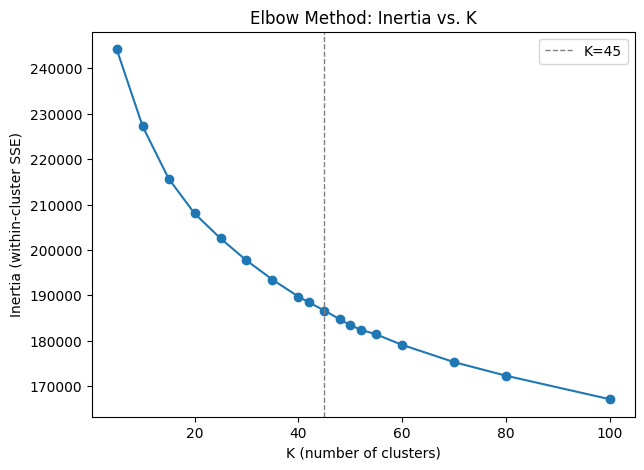

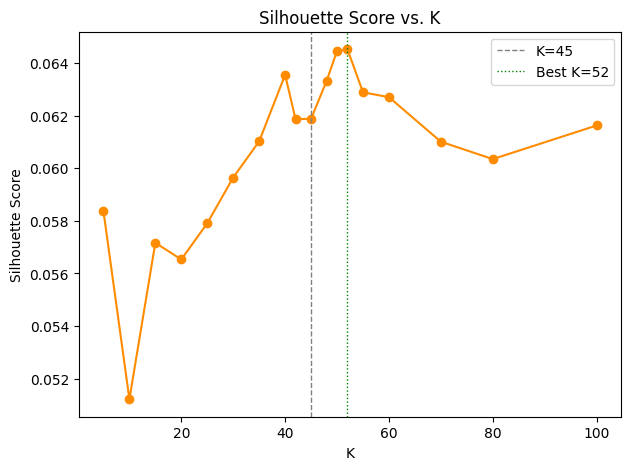

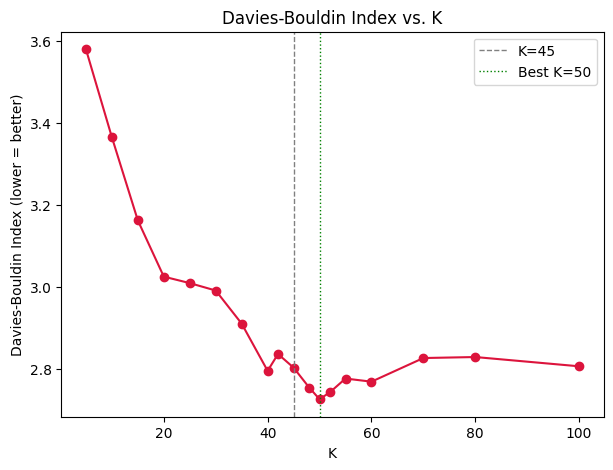

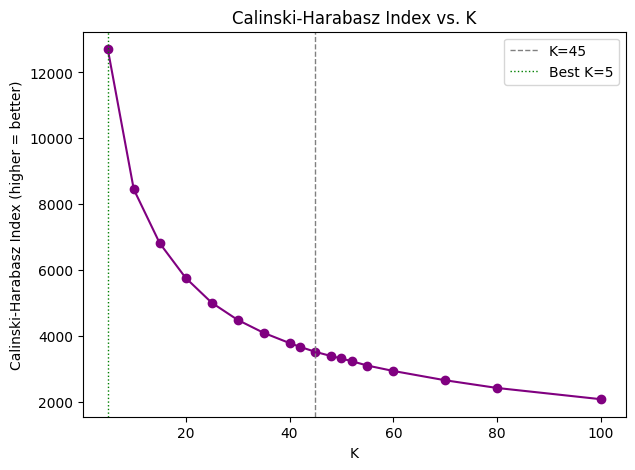

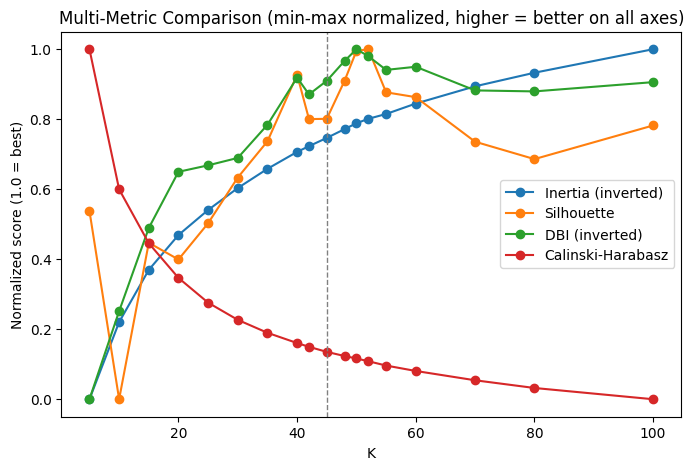

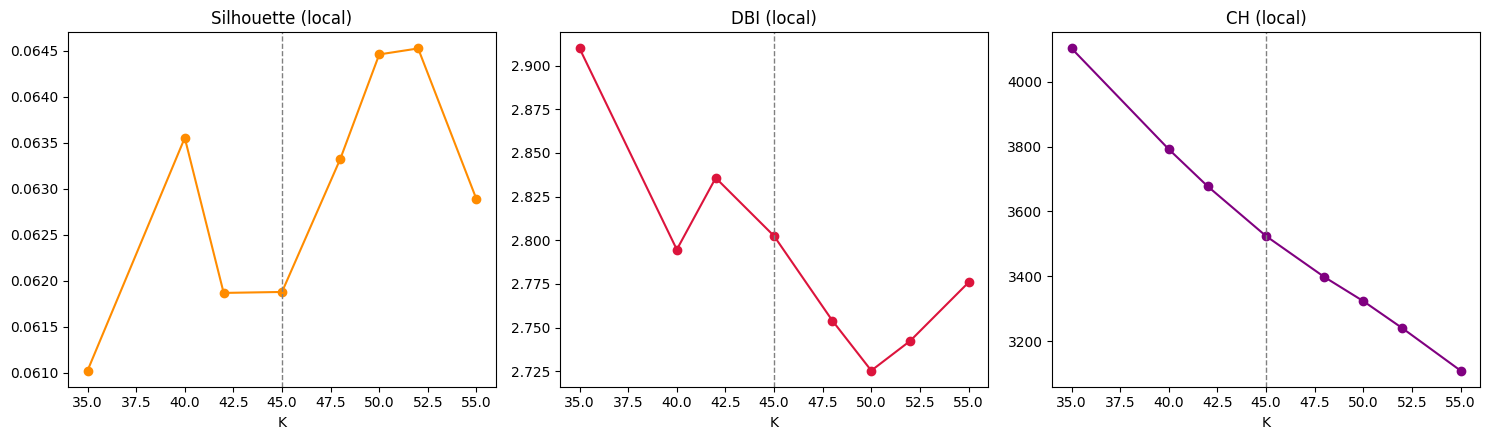

In [5]:
import matplotlib.pyplot as plt

tuning_df = pd.read_csv("/content/k_tuning_results.csv").sort_values("K")
K = tuning_df["K"].values

def save_fig(fig, name):
    fig.savefig(f"/content/{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"/content/{name}.pdf", bbox_inches="tight")
    print(f"Saved {name}.png / {name}.pdf")

# --- Figure 1: Elbow curve ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(K, tuning_df["Inertia"], marker="o", color="#1f77b4")
ax.axvline(45, color="gray", linestyle="--", linewidth=1, label="K=45")
ax.set_xlabel("K (number of clusters)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("Elbow Method: Inertia vs. K")
ax.legend()
save_fig(fig, "fig1_elbow")

# --- Figure 2: Silhouette vs K ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(K, tuning_df["Silhouette"], marker="o", color="darkorange")
best_k_sil = int(tuning_df.loc[tuning_df["Silhouette"].idxmax(), "K"])
ax.axvline(45, color="gray", linestyle="--", linewidth=1, label="K=45")
ax.axvline(best_k_sil, color="green", linestyle=":", linewidth=1, label=f"Best K={best_k_sil}")
ax.set_xlabel("K"); ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs. K")
ax.legend()
save_fig(fig, "fig2_silhouette")

# --- Figure 3: Davies-Bouldin vs K (lower is better) ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(K, tuning_df["Davies_Bouldin"], marker="o", color="crimson")
best_k_dbi = int(tuning_df.loc[tuning_df["Davies_Bouldin"].idxmin(), "K"])
ax.axvline(45, color="gray", linestyle="--", linewidth=1, label="K=45")
ax.axvline(best_k_dbi, color="green", linestyle=":", linewidth=1, label=f"Best K={best_k_dbi}")
ax.set_xlabel("K"); ax.set_ylabel("Davies-Bouldin Index (lower = better)")
ax.set_title("Davies-Bouldin Index vs. K")
ax.legend()
save_fig(fig, "fig3_dbi")

# --- Figure 4: Calinski-Harabasz vs K (higher is better) ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(K, tuning_df["Calinski_Harabasz"], marker="o", color="purple")
best_k_ch = int(tuning_df.loc[tuning_df["Calinski_Harabasz"].idxmax(), "K"])
ax.axvline(45, color="gray", linestyle="--", linewidth=1, label="K=45")
ax.axvline(best_k_ch, color="green", linestyle=":", linewidth=1, label=f"Best K={best_k_ch}")
ax.set_xlabel("K"); ax.set_ylabel("Calinski-Harabasz Index (higher = better)")
ax.set_title("Calinski-Harabasz Index vs. K")
ax.legend()
save_fig(fig, "fig4_ch")

# --- Figure 5: Multi-metric normalized comparison ---
# Min-max normalize each metric to [0,1] SEPARATELY, then flip DBI and
# Inertia (lower=better) so that 1.0 = best on every metric consistently.
norm = pd.DataFrame({"K": K})
norm["Inertia_norm"]      = 1 - (tuning_df["Inertia"] - tuning_df["Inertia"].min()) / (tuning_df["Inertia"].max() - tuning_df["Inertia"].min())
norm["Silhouette_norm"]   = (tuning_df["Silhouette"] - tuning_df["Silhouette"].min()) / (tuning_df["Silhouette"].max() - tuning_df["Silhouette"].min())
norm["DBI_norm"]          = 1 - (tuning_df["Davies_Bouldin"] - tuning_df["Davies_Bouldin"].min()) / (tuning_df["Davies_Bouldin"].max() - tuning_df["Davies_Bouldin"].min())
norm["CH_norm"]           = (tuning_df["Calinski_Harabasz"] - tuning_df["Calinski_Harabasz"].min()) / (tuning_df["Calinski_Harabasz"].max() - tuning_df["Calinski_Harabasz"].min())

fig, ax = plt.subplots(figsize=(8, 5))
for col, label in [("Inertia_norm","Inertia (inverted)"), ("Silhouette_norm","Silhouette"),
                    ("DBI_norm","DBI (inverted)"), ("CH_norm","Calinski-Harabasz")]:
    ax.plot(norm["K"], norm[col], marker="o", label=label)
ax.axvline(45, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("K"); ax.set_ylabel("Normalized score (1.0 = best)")
ax.set_title("Multi-Metric Comparison (min-max normalized, higher = better on all axes)")
ax.legend()
save_fig(fig, "fig5_multimetric")

# --- Figure 6: Local comparison around K=45 ---
local = tuning_df[tuning_df["K"].between(35, 55)]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].plot(local["K"], local["Silhouette"], marker="o", color="darkorange"); ax[0].set_title("Silhouette (local)")
ax[1].plot(local["K"], local["Davies_Bouldin"], marker="o", color="crimson"); ax[1].set_title("DBI (local)")
ax[2].plot(local["K"], local["Calinski_Harabasz"], marker="o", color="purple"); ax[2].set_title("CH (local)")
for a in ax:
    a.axvline(45, color="gray", linestyle="--", linewidth=1)
    a.set_xlabel("K")
plt.tight_layout()
save_fig(fig, "fig6_local_around_45")

In [8]:
!pip install python-docx --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.2 MB/s eta 0:00:00


In [9]:
# ============================================================
# PUBLICATION-READY TABLE GENERATION PIPELINE
# Reads k_tuning_results.csv (produced by the Section-6 sweep experiment)
# and generates:
#   - Full tuning table:   CSV, XLSX, LaTeX (.tex), PNG, PDF
#   - Local/selection table (candidates around SELECTED_K): same formats
#   - A Word-ready .docx table
#
# This script contains NO hardcoded metric values. Every number in every
# output file is read directly from k_tuning_results.csv. If that CSV
# changes, re-running this script regenerates every downstream file.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.table import Table

# --------------------------------------------------------------
# CONFIG — the only two things you should need to edit
# --------------------------------------------------------------
RESULTS_CSV = "k_tuning_results.csv"   # output of the Section-6 sweep
SELECTED_K = 45                        # the K you are selecting/defending
LOCAL_WINDOW = 10                      # +/- around SELECTED_K for Table 2
OUT_PREFIX_FULL = "table1_full_tuning"
OUT_PREFIX_LOCAL = "table2_local_selection"

# --------------------------------------------------------------
# 1. LOAD + CLEAN
# --------------------------------------------------------------
df = pd.read_csv(RESULTS_CSV)

required_cols = {"K", "Inertia", "Silhouette", "Davies_Bouldin", "Calinski_Harabasz"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"results CSV is missing expected columns: {missing}")

df = df.sort_values("K").reset_index(drop=True)

if SELECTED_K not in df["K"].values:
    raise ValueError(
        f"SELECTED_K={SELECTED_K} was not found in {RESULTS_CSV}. "
        f"K values actually tested: {sorted(df['K'].unique())}. "
        f"Do not fabricate a row for an untested K — re-run the sweep "
        f"to include it instead."
    )

# --------------------------------------------------------------
# 2. FORMAT for academic presentation
#    (rounding only for display copies — raw CSV stays full precision)
# --------------------------------------------------------------
def make_display_df(source_df):
    disp = source_df.copy()
    disp["Inertia"] = disp["Inertia"].round(1)
    disp["Silhouette"] = disp["Silhouette"].round(4)
    disp["Davies_Bouldin"] = disp["Davies_Bouldin"].round(4)
    disp["Calinski_Harabasz"] = disp["Calinski_Harabasz"].round(1)
    if "Runtime_sec" in disp.columns:
        disp["Runtime_min"] = (disp["Runtime_sec"] / 60).round(2)
        disp = disp.drop(columns=["Runtime_sec"])

    disp["Selection"] = np.where(disp["K"] == SELECTED_K, "Selected", "")

    disp = disp.rename(columns={
        "K": "K",
        "Inertia": "Inertia",
        "Silhouette": "Silhouette Score",
        "Davies_Bouldin": "Davies-Bouldin Index",
        "Calinski_Harabasz": "Calinski-Harabasz Index",
        "Runtime_min": "Runtime (min)",
    })
    return disp

full_display = make_display_df(df)

# Column order, no implementation/debugging columns
FULL_COLS = ["K", "Inertia", "Silhouette Score", "Davies-Bouldin Index",
             "Calinski-Harabasz Index", "Runtime (min)", "Selection"]
full_display = full_display[[c for c in FULL_COLS if c in full_display.columns]]

# --------------------------------------------------------------
# 3. Table 2 — local window around SELECTED_K (only tested K values)
# --------------------------------------------------------------
low, high = SELECTED_K - LOCAL_WINDOW, SELECTED_K + LOCAL_WINDOW
local_df = df[df["K"].between(low, high)].copy()
local_display = make_display_df(local_df)

def interpret(row):
    if row["K"] == SELECTED_K:
        return "Selected"
    return ""

local_display["Interpretation"] = local_display.apply(interpret, axis=1)
local_display = local_display.drop(columns=["Selection"])
LOCAL_COLS = ["K", "Silhouette Score", "Davies-Bouldin Index",
              "Calinski-Harabasz Index", "Inertia", "Interpretation"]
local_display = local_display[[c for c in LOCAL_COLS if c in local_display.columns]]

# --------------------------------------------------------------
# 4. SAVE — CSV, XLSX (per table)
# --------------------------------------------------------------
def save_csv_xlsx(display_df, prefix):
    display_df.to_csv(f"{prefix}.csv", index=False)

    with pd.ExcelWriter(f"{prefix}.xlsx", engine="openpyxl") as writer:
        display_df.to_excel(writer, index=False, sheet_name="results")
        ws = writer.sheets["results"]
        # bold the header row + selected row, autosize columns
        from openpyxl.styles import Font, PatternFill
        for cell in ws[1]:
            cell.font = Font(bold=True)
        sel_col_idx = list(display_df.columns).index(
            "Selection" if "Selection" in display_df.columns else "Interpretation"
        ) + 1
        for row_idx in range(2, ws.max_row + 1):
            marker = ws.cell(row=row_idx, column=sel_col_idx).value
            if marker == "Selected":
                for cell in ws[row_idx]:
                    cell.font = Font(bold=True)
                    cell.fill = PatternFill(start_color="FFF2CC", end_color="FFF2CC", fill_type="solid")
        for col_cells in ws.columns:
            length = max(len(str(c.value)) for c in col_cells)
            ws.column_dimensions[col_cells[0].column_letter].width = length + 3
    print(f"Saved {prefix}.csv and {prefix}.xlsx")

save_csv_xlsx(full_display, OUT_PREFIX_FULL)
save_csv_xlsx(local_display, OUT_PREFIX_LOCAL)

# --------------------------------------------------------------
# 5. SAVE — LaTeX (.tex), booktabs style, bold selected row
# --------------------------------------------------------------
def to_latex(display_df, caption, label, prefix, sel_col):
    cols = list(display_df.columns)
    n_cols = len(cols)
    col_spec = "l" + "r" * (n_cols - 2) + "l"  # K left, metrics right, sel/interp left

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{" + caption + "}")
    lines.append(r"\label{" + label + "}")
    lines.append(r"\begin{tabular}{" + col_spec + "}")
    lines.append(r"\toprule")
    lines.append(" & ".join(cols) + r" \\")
    lines.append(r"\midrule")
    for _, row in display_df.iterrows():
        cells = []
        is_selected = row.get(sel_col, "") == "Selected"
        for c in cols:
            val = row[c]
            cell = f"{val}"
            if is_selected:
                cell = r"\textbf{" + cell + "}"
            cells.append(cell)
        lines.append(" & ".join(cells) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    with open(f"{prefix}.tex", "w") as f:
        f.write("\n".join(lines))
    print(f"Saved {prefix}.tex")

FULL_CAPTION = (
    f"Internal clustering validation metrics across candidate values of K "
    f"({int(df['K'].min())}--{int(df['K'].max())}). Silhouette Score and "
    f"Calinski-Harabasz Index: higher is better. Davies-Bouldin Index: "
    f"lower is better. K={SELECTED_K} (bold) denotes the selected configuration."
)
LOCAL_CAPTION = (
    f"Local comparison of internal validation metrics for candidate K values "
    f"in the range [{low}, {high}] tested during hyperparameter tuning. "
    f"K={SELECTED_K} (bold) denotes the selected configuration."
)

to_latex(full_display, FULL_CAPTION, "tab:k_tuning_full", OUT_PREFIX_FULL, "Selection")
to_latex(local_display, LOCAL_CAPTION, "tab:k_tuning_local", OUT_PREFIX_LOCAL, "Interpretation")

# --------------------------------------------------------------
# 6. SAVE — high-res PNG / PDF table image (matplotlib table render)
# --------------------------------------------------------------
def render_table_image(display_df, caption, prefix, sel_col):
    n_rows, n_cols = display_df.shape
    col_labels = list(display_df.columns)
    cell_text = display_df.astype(str).values

    # column widths proportional to the widest entry (header or data) in
    # that column, in characters -- avoids header text overlapping into
    # the next column for long labels like "Davies-Bouldin Index"
    char_widths = [
        max([len(str(col_labels[j]))] + [len(str(v)) for v in cell_text[:, j]])
        for j in range(n_cols)
    ]
    total_chars = sum(char_widths)
    col_fracs = [w / total_chars for w in char_widths]

    fig_h = 0.45 * (n_rows + 2)
    fig_w = max(0.11 * total_chars, 8)  # scale figure width to content
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center",
                    cellLoc="center", colWidths=col_fracs)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)

    # style header row
    for j in range(n_cols):
        cell = tbl[0, j]
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#2E4057")

    # bold + highlight selected row
    for i in range(n_rows):
        if display_df.iloc[i][sel_col] == "Selected":
            for j in range(n_cols):
                cell = tbl[i + 1, j]
                cell.set_text_props(weight="bold")
                cell.set_facecolor("#FFF2CC")

    ax.set_title(caption, fontsize=9, wrap=True, pad=18)
    fig.tight_layout()
    fig.savefig(f"{prefix}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{prefix}.pdf", bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {prefix}.png and {prefix}.pdf")

render_table_image(full_display, FULL_CAPTION, OUT_PREFIX_FULL, "Selection")
render_table_image(local_display, LOCAL_CAPTION, OUT_PREFIX_LOCAL, "Interpretation")

# --------------------------------------------------------------
# 7. SAVE — Word-ready .docx table
# --------------------------------------------------------------
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

def render_docx_table(display_df, caption, prefix, sel_col, table_number):
    doc = Document()

    cap = doc.add_paragraph()
    cap_run = cap.add_run(f"Table {table_number}. {caption}")
    cap_run.italic = True
    cap_run.font.size = Pt(10)

    n_rows, n_cols = display_df.shape
    table = doc.add_table(rows=n_rows + 1, cols=n_cols)
    table.style = "Light Grid Accent 1"

    for j, col in enumerate(display_df.columns):
        cell = table.cell(0, j)
        cell.text = str(col)
        for p in cell.paragraphs:
            for r in p.runs:
                r.font.bold = True
                r.font.size = Pt(10)

    for i in range(n_rows):
        is_selected = display_df.iloc[i][sel_col] == "Selected"
        for j, col in enumerate(display_df.columns):
            cell = table.cell(i + 1, j)
            cell.text = str(display_df.iloc[i][col])
            for p in cell.paragraphs:
                p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                for r in p.runs:
                    r.font.size = Pt(10)
                    if is_selected:
                        r.font.bold = True

    doc.save(f"{prefix}.docx")
    print(f"Saved {prefix}.docx")

render_docx_table(full_display, FULL_CAPTION, OUT_PREFIX_FULL, "Selection", table_number=1)
render_docx_table(local_display, LOCAL_CAPTION, OUT_PREFIX_LOCAL, "Interpretation", table_number=2)

print("\nAll table formats generated from", RESULTS_CSV)
print("Full table row count:", len(full_display), "| Local table row count:", len(local_display))


Saved table1_full_tuning.csv and table1_full_tuning.xlsx
Saved table2_local_selection.csv and table2_local_selection.xlsx
Saved table1_full_tuning.tex
Saved table2_local_selection.tex
Saved table1_full_tuning.png and table1_full_tuning.pdf
Saved table2_local_selection.png and table2_local_selection.pdf
Saved table1_full_tuning.docx
Saved table2_local_selection.docx

All table formats generated from k_tuning_results.csv
Full table row count: 18 | Local table row count: 8


In [11]:
# ============================================================
# SAVE EVERYTHING TO GOOGLE DRIVE
# Run this AFTER you've run the sweep, the figures code, and
# generate_paper_tables.py — it just collects what already
# exists in /content/ and copies it to Drive. Nothing is
# regenerated here.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# Destination folder on your Drive — change the name if you want
DEST_DIR = "/content/drive/My Drive/arxiv_clustering_paper_outputs"
os.makedirs(DEST_DIR, exist_ok=True)

# Every file this pipeline can produce, across all three scripts.
# Missing ones are skipped with a printed note (e.g. if you haven't
# run the exploration sweep, or skipped the .docx step) — nothing
# breaks if some aren't present.
FILES_TO_SAVE = [
    # --- Raw tuning results ---
    "/content/k_tuning_results.csv",
    "/content/k_tuning_results_EXPLORATION.csv",

    # --- Figures (Section 6-9 figure code) ---
    "/content/fig1_elbow.png",
    "/content/fig1_elbow.pdf",
    "/content/fig2_silhouette.png",
    "/content/fig2_silhouette.pdf",
    "/content/fig3_dbi.png",
    "/content/fig3_dbi.pdf",
    "/content/fig4_ch.png",
    "/content/fig4_ch.pdf",
    "/content/fig5_multimetric.png",
    "/content/fig5_multimetric.pdf",
    "/content/fig6_local_around_45.png",
    "/content/fig6_local_around_45.pdf",

    # --- Table 1: full tuning table (generate_paper_tables.py) ---
    "/content/table1_full_tuning.csv",
    "/content/table1_full_tuning.xlsx",
    "/content/table1_full_tuning.tex",
    "/content/table1_full_tuning.png",
    "/content/table1_full_tuning.pdf",
    "/content/table1_full_tuning.docx",

    # --- Table 2: local selection table ---
    "/content/table2_local_selection.csv",
    "/content/table2_local_selection.xlsx",
    "/content/table2_local_selection.tex",
    "/content/table2_local_selection.png",
    "/content/table2_local_selection.pdf",
    "/content/table2_local_selection.docx",
]

saved, missing = [], []
for path in FILES_TO_SAVE:
    if os.path.exists(path):
        shutil.copy(path, DEST_DIR)
        saved.append(os.path.basename(path))
    else:
        missing.append(os.path.basename(path))

print(f"Saved {len(saved)} file(s) to: {DEST_DIR}\n")
for f in saved:
    print("  ✓", f)

if missing:
    print(f"\nSkipped {len(missing)} file(s) not found in /content/ (fine if you haven't generated them yet):")
    for f in missing:
        print("  -", f)

Mounted at /content/drive
Saved 25 file(s) to: /content/drive/My Drive/arxiv_clustering_paper_outputs

  ✓ k_tuning_results.csv
  ✓ fig1_elbow.png
  ✓ fig1_elbow.pdf
  ✓ fig2_silhouette.png
  ✓ fig2_silhouette.pdf
  ✓ fig3_dbi.png
  ✓ fig3_dbi.pdf
  ✓ fig4_ch.png
  ✓ fig4_ch.pdf
  ✓ fig5_multimetric.png
  ✓ fig5_multimetric.pdf
  ✓ fig6_local_around_45.png
  ✓ fig6_local_around_45.pdf
  ✓ table1_full_tuning.csv
  ✓ table1_full_tuning.xlsx
  ✓ table1_full_tuning.tex
  ✓ table1_full_tuning.png
  ✓ table1_full_tuning.pdf
  ✓ table1_full_tuning.docx
  ✓ table2_local_selection.csv
  ✓ table2_local_selection.xlsx
  ✓ table2_local_selection.tex
  ✓ table2_local_selection.png
  ✓ table2_local_selection.pdf
  ✓ table2_local_selection.docx

Skipped 1 file(s) not found in /content/ (fine if you haven't generated them yet):
  - k_tuning_results_EXPLORATION.csv
